**Setup**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

PROJECT_ROOT = Path("/content/drive/MyDrive/Dissertation")

RESULTS_DIR = PROJECT_ROOT / "05_Results" / "image_models"
FIGURE_DIR = RESULTS_DIR / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Results folder exists:", RESULTS_DIR.exists())

Mounted at /content/drive
Results folder exists: True


**Load saved results**

In [2]:
eff_history = pd.read_csv(
    RESULTS_DIR / "efficientnetv2s_training_history.csv"
)

conv_history = pd.read_csv(
    RESULTS_DIR / "convnext_tiny_training_history.csv"
)

model_comparison = pd.read_csv(
    RESULTS_DIR / "image_model_validation_comparison.csv"
)

test_metrics = pd.read_csv(
    RESULTS_DIR / "final_image_test_metrics.csv"
)

test_predictions = pd.read_csv(
    RESULTS_DIR / "final_image_test_predictions.csv"
)

print("EfficientNet history:", eff_history.shape)
print("ConvNeXt history:", conv_history.shape)
print("Test predictions:", test_predictions.shape)

EfficientNet history: (9, 9)
ConvNeXt history: (15, 9)
Test predictions: (317, 8)


**Validation model comparison**

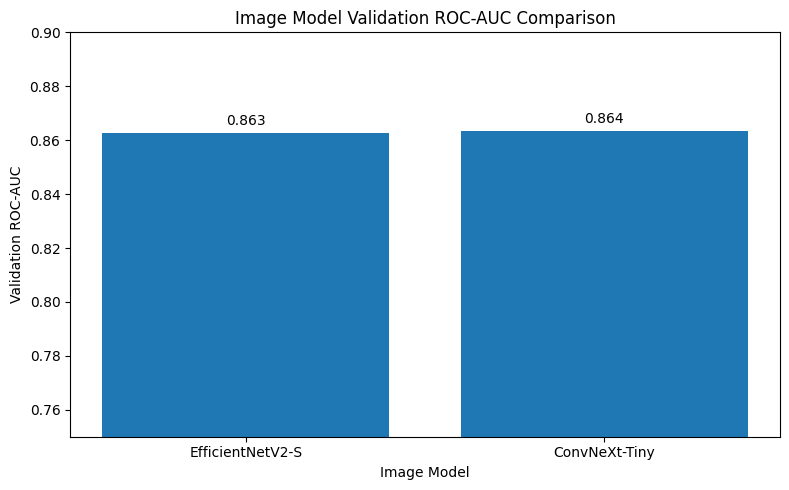

In [3]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["model"],
    model_comparison["val_roc_auc"]
)

plt.ylabel("Validation ROC-AUC")
plt.xlabel("Image Model")
plt.title("Image Model Validation ROC-AUC Comparison")
plt.ylim(0.75, 0.90)

for i, value in enumerate(model_comparison["val_roc_auc"]):
    plt.text(i, value + 0.003, f"{value:.3f}", ha="center")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "01_image_model_validation_roc_auc_comparison.png", dpi=300)
plt.show()

**Validation metrics comparison**

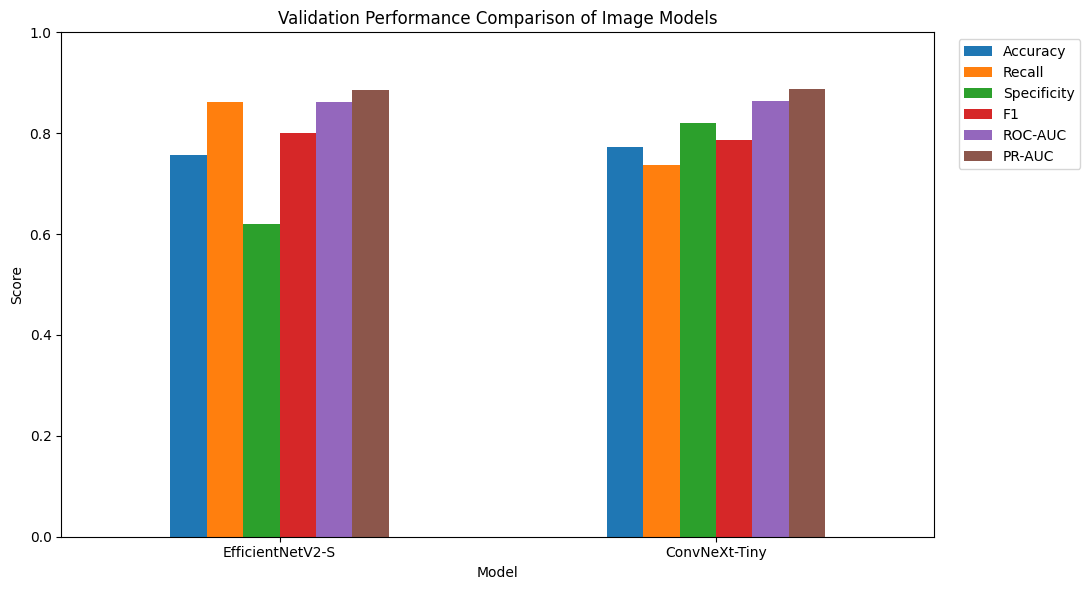

In [4]:
metrics = [
    "val_accuracy",
    "val_recall",
    "val_specificity",
    "val_f1",
    "val_roc_auc",
    "val_pr_auc"
]

plot_df = model_comparison.set_index("model")[metrics]

plot_df.plot(kind="bar", figsize=(11, 6))

plt.ylabel("Score")
plt.xlabel("Model")
plt.title("Validation Performance Comparison of Image Models")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(
    ["Accuracy", "Recall", "Specificity", "F1", "ROC-AUC", "PR-AUC"],
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "02_image_model_validation_metrics_comparison.png", dpi=300)
plt.show()

**Training and validation loss curves**

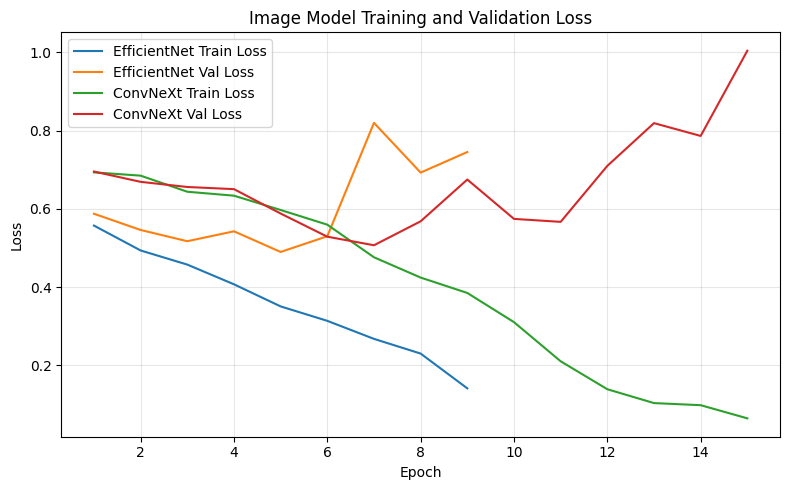

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(
    eff_history["epoch"],
    eff_history["train_loss"],
    label="EfficientNet Train Loss"
)

plt.plot(
    eff_history["epoch"],
    eff_history["val_loss"],
    label="EfficientNet Val Loss"
)

plt.plot(
    conv_history["epoch"],
    conv_history["train_loss"],
    label="ConvNeXt Train Loss"
)

plt.plot(
    conv_history["epoch"],
    conv_history["val_loss"],
    label="ConvNeXt Val Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Image Model Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "03_image_model_loss_curves.png", dpi=300)
plt.show()

**Validation ROC-AUC by epoch**

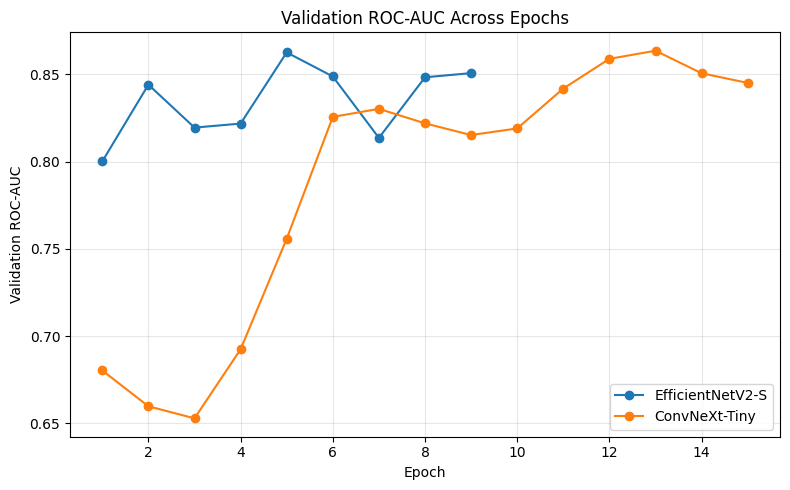

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(
    eff_history["epoch"],
    eff_history["val_roc_auc"],
    marker="o",
    label="EfficientNetV2-S"
)

plt.plot(
    conv_history["epoch"],
    conv_history["val_roc_auc"],
    marker="o",
    label="ConvNeXt-Tiny"
)

plt.xlabel("Epoch")
plt.ylabel("Validation ROC-AUC")
plt.title("Validation ROC-AUC Across Epochs")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "04_validation_roc_auc_by_epoch.png", dpi=300)
plt.show()

**Final test confusion matrix**

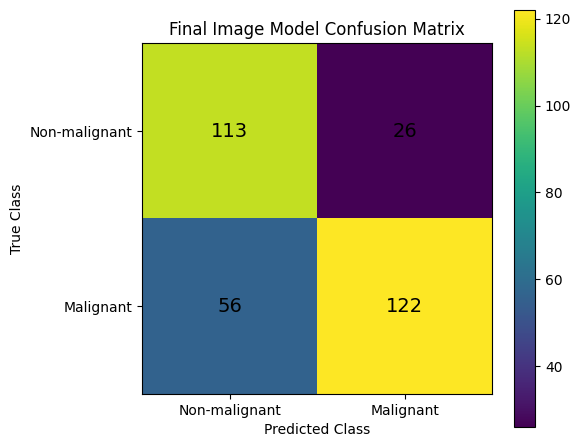

array([[113,  26],
       [ 56, 122]])

In [7]:
y_true = test_predictions["target"].values
y_pred = test_predictions["prediction"].values
y_prob = test_predictions["malignant_probability"].values

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Final Image Model Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks([0, 1], ["Non-malignant", "Malignant"])
plt.yticks([0, 1], ["Non-malignant", "Malignant"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)

plt.colorbar()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "05_final_image_test_confusion_matrix.png", dpi=300)
plt.show()

cm

Final test ROC curve

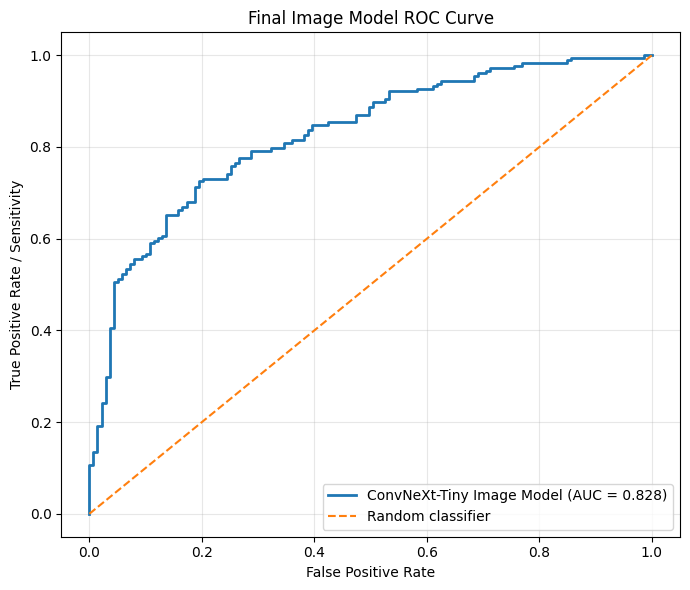

In [8]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ConvNeXt-Tiny Image Model (AUC = {roc_auc_value:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensitivity")
plt.title("Final Image Model ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "06_final_image_test_roc_curve.png", dpi=300)
plt.show()

**Final test precision-recall curve**

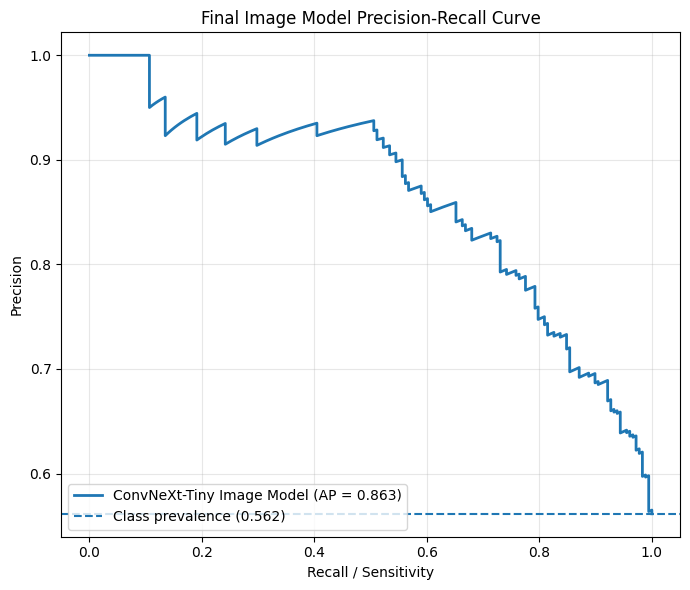

In [9]:
precision, recall, thresholds_pr = precision_recall_curve(y_true, y_prob)
pr_auc_value = average_precision_score(y_true, y_prob)
baseline = y_true.mean()

plt.figure(figsize=(7, 6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"ConvNeXt-Tiny Image Model (AP = {pr_auc_value:.3f})"
)

plt.axhline(
    y=baseline,
    linestyle="--",
    label=f"Class prevalence ({baseline:.3f})"
)

plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.title("Final Image Model Precision-Recall Curve")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "07_final_image_test_precision_recall_curve.png", dpi=300)
plt.show()

**Probability distribution**

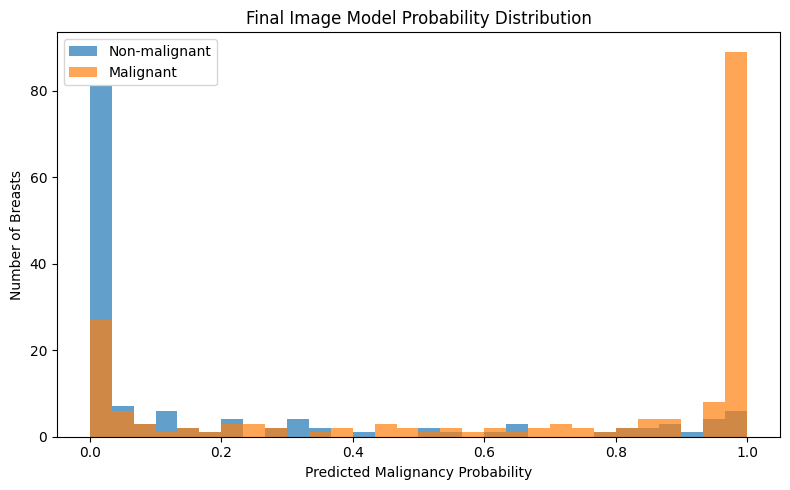

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(
    test_predictions[test_predictions["target"] == 0]["malignant_probability"],
    bins=30,
    alpha=0.7,
    label="Non-malignant"
)

plt.hist(
    test_predictions[test_predictions["target"] == 1]["malignant_probability"],
    bins=30,
    alpha=0.7,
    label="Malignant"
)

plt.xlabel("Predicted Malignancy Probability")
plt.ylabel("Number of Breasts")
plt.title("Final Image Model Probability Distribution")
plt.legend()

plt.tight_layout()
plt.savefig(FIGURE_DIR / "08_final_image_probability_distribution.png", dpi=300)
plt.show()

**Save figure index**

In [11]:
figure_index = pd.DataFrame({
    "figure_number": list(range(1, 9)),
    "figure": [
        "Image Model Validation ROC-AUC Comparison",
        "Image Model Validation Metrics Comparison",
        "Training and Validation Loss Curves",
        "Validation ROC-AUC by Epoch",
        "Final Image Model Confusion Matrix",
        "Final Image Model ROC Curve",
        "Final Image Model Precision-Recall Curve",
        "Final Image Model Probability Distribution"
    ],
    "filename": [
        "01_image_model_validation_roc_auc_comparison.png",
        "02_image_model_validation_metrics_comparison.png",
        "03_image_model_loss_curves.png",
        "04_validation_roc_auc_by_epoch.png",
        "05_final_image_test_confusion_matrix.png",
        "06_final_image_test_roc_curve.png",
        "07_final_image_test_precision_recall_curve.png",
        "08_final_image_probability_distribution.png"
    ]
})

figure_index.to_csv(
    FIGURE_DIR / "image_model_figure_index.csv",
    index=False
)

print("Image model visualisations complete.")
print("Saved to:", FIGURE_DIR)

Image model visualisations complete.
Saved to: /content/drive/MyDrive/Dissertation/05_Results/image_models/figures
